In [ ]:
# ==============================
# STEP 1: Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Leads Data Dictionary.xlsx to Leads Data Dictionary (1).xlsx


In [ ]:
# Load dataset
df = pd.read_csv("Lead Scoring.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
# First 5 rows
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (9240, 37)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [9]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

,0
Lead Quality,4767
Asymmetrique Profile Score,4218
Asymmetrique Activity Index,4218
Asymmetrique Activity Score,4218
Asymmetrique Profile Index,4218
Tags,3353
What matters most to you in choosing a course,2709
Lead Profile,2709
What is your current occupation,2690
Country,2461


In [10]:
# Percentage of missing values

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percent
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df = missing_df.sort_values(by="Percentage", ascending=False)

missing_df

,Missing Values,Percentage
Lead Quality,4767,51.590909
Asymmetrique Profile Score,4218,45.649351
Asymmetrique Activity Index,4218,45.649351
Asymmetrique Activity Score,4218,45.649351
Asymmetrique Profile Index,4218,45.649351
Tags,3353,36.287879
What matters most to you in choosing a course,2709,29.318182
Lead Profile,2709,29.318182
What is your current occupation,2690,29.112554
Country,2461,26.634199


In [11]:
# Drop columns having more than 40% missing values

threshold = 40

cols_to_drop = missing_df[missing_df["Percentage"] > threshold].index

print("Columns to Drop:")
print(cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)

print("\nNew Shape:", df.shape)

Columns to Drop:
Index(['Lead Quality', 'Asymmetrique Profile Score',
       'Asymmetrique Activity Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Index'],
      dtype='object')

New Shape: (9240, 32)


In [12]:
# Fill missing values

for col in df.columns:

    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


In [13]:
df.isnull().sum().sort_values(ascending=False)

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,0
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,0
Total Time Spent on Website,0
Page Views Per Visit,0


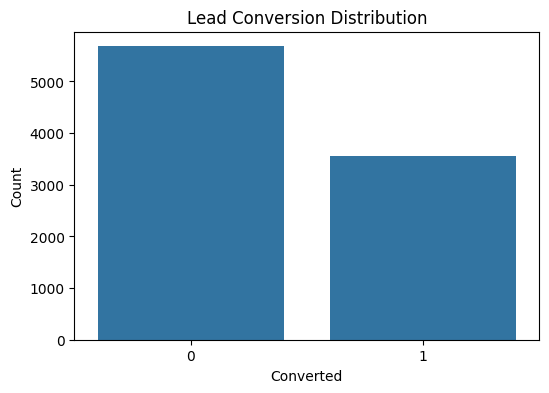

Converted
0    5679
1    3561
Name: count, dtype: int64


In [14]:
# Target Variable Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='Converted', data=df)

plt.title("Lead Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Count")

plt.show()

print(df["Converted"].value_counts())

In [15]:
conversion_rate = df["Converted"].value_counts(normalize=True) * 100

print(conversion_rate)

Converted
0    61.461039
1    38.538961
Name: proportion, dtype: float64


In [16]:
df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000
mean,617188.435606,0.385390,3.438636,487.698268,2.357440
std,23405.995698,0.486714,4.819024,548.021466,2.145781
min,579533.000000,0.000000,0.000000,0.000000,0.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000


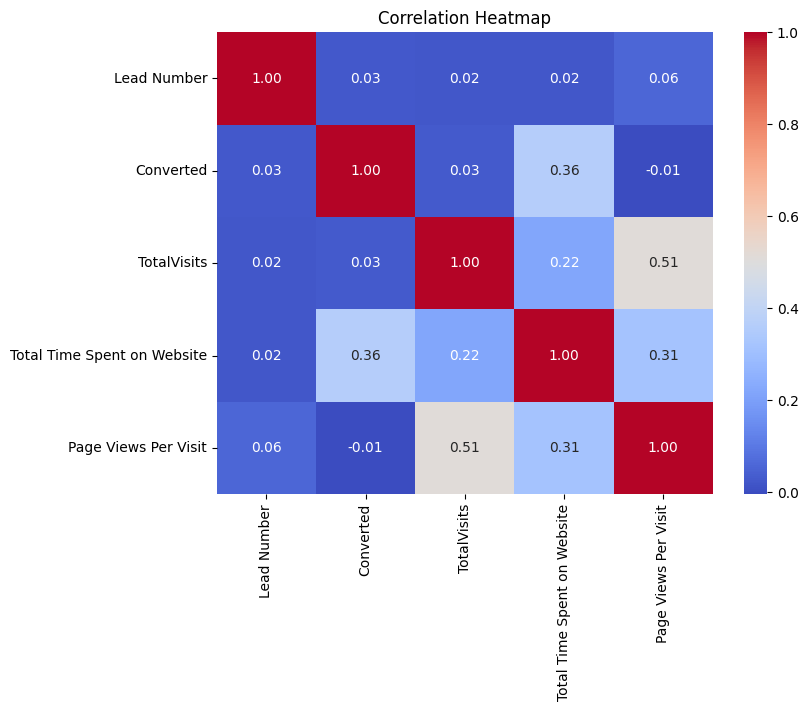

In [17]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

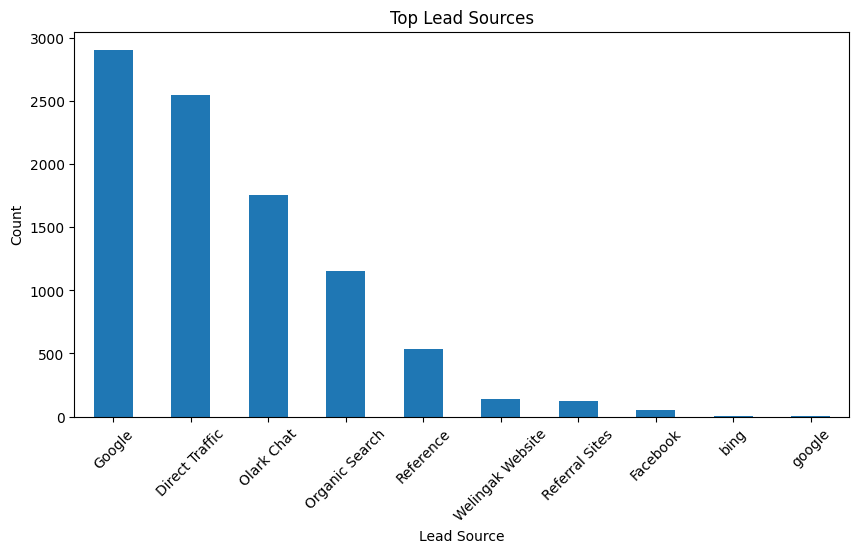

In [18]:
plt.figure(figsize=(10,5))

df["Lead Source"].value_counts().head(10).plot(kind="bar")

plt.title("Top Lead Sources")
plt.xlabel("Lead Source")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

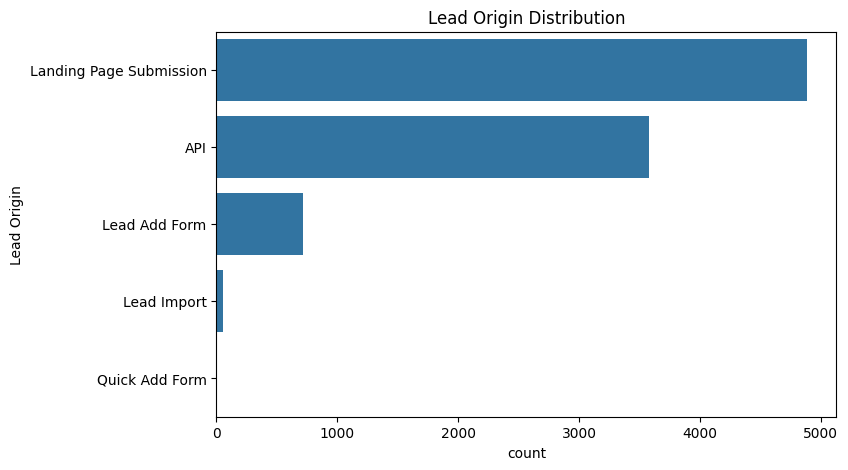

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="Lead Origin",
    data=df,
    order=df["Lead Origin"].value_counts().index
)

plt.title("Lead Origin Distribution")

plt.show()

In [20]:
# Encode all categorical columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

print("Encoding Completed!")

Encoding Completed!


In [21]:
X = df.drop("Converted", axis=1)
y = df["Converted"]

print(X.shape)
print(y.shape)

(9240, 31)
(9240,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7392, 31)
(1848, 31)


In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [24]:
y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print("\nROC AUC :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.7662337662337663

ROC AUC : 0.8185914998417472

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.85      0.82      1136
           1       0.72      0.64      0.68       712

    accuracy                           0.77      1848
   macro avg       0.76      0.74      0.75      1848
weighted avg       0.76      0.77      0.76      1848


Confusion Matrix

[[960 176]
 [256 456]]


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [28]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [29]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("\nROC AUC :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.8971861471861472

ROC AUC : 0.959676422297832

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1136
           1       0.88      0.85      0.86       712

    accuracy                           0.90      1848
   macro avg       0.89      0.89      0.89      1848
weighted avg       0.90      0.90      0.90      1848


Confusion Matrix

[[1055   81]
 [ 109  603]]


In [30]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.766234,0.818591
1,Random Forest,0.897186,0.959676


In [31]:
lead_scores = (y_prob_rf * 100).round(2)

results = X_test.copy()

results["Actual"] = y_test.values
results["Prediction"] = y_pred_rf
results["Lead Score"] = lead_scores

results.head(10)

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,...,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,Actual,Prediction,Lead Score
683,4875,653523,1,11,0,0,6.0,1505,6.0,10,...,0,0,4,1,0,1,10,1,1,53.0
1931,5413,640972,0,6,0,0,0.0,0,0.0,12,...,0,0,3,4,0,0,8,1,1,65.0
6950,5597,596345,1,1,0,0,2.0,310,2.0,12,...,0,0,4,3,0,1,12,0,0,6.0
2996,4606,631108,1,1,0,0,3.0,307,3.0,5,...,0,0,4,0,0,1,4,0,0,0.5
3902,8931,622617,1,1,0,0,4.0,234,4.0,3,...,0,0,4,5,0,1,2,0,0,7.5
6828,4556,597334,1,1,0,0,11.0,420,5.5,5,...,0,0,4,1,0,1,4,0,0,8.5
4906,4343,612899,0,3,0,0,2.0,102,2.0,12,...,0,0,4,0,0,0,12,0,1,67.0
5796,8530,605302,0,6,0,0,0.0,0,0.0,9,...,0,0,4,4,0,0,9,0,0,22.0
6388,3039,600932,0,6,0,0,0.0,0,0.0,5,...,0,0,4,0,0,0,4,0,0,0.0
3636,7162,625590,0,15,0,0,1.0,458,1.0,1,...,0,0,4,0,0,0,8,0,0,11.5


In [32]:
def priority(score):
    if score >= 80:
        return "High"

    elif score >= 60:
        return "Medium"

    else:
        return "Low"

results["Priority"] = results["Lead Score"].apply(priority)

results[["Lead Score","Priority"]].head(10)

,Lead Score,Priority
683,53.0,Low
1931,65.0,Medium
6950,6.0,Low
2996,0.5,Low
3902,7.5,Low
6828,8.5,Low
4906,67.0,Medium
5796,22.0,Low
6388,0.0,Low
3636,11.5,Low


In [39]:
# ==========================================
# Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("="*60)
print("TOP 10 IMPORTANT FEATURES")
print("="*60)

print(feature_importance.head(10))

feature_importance.head(10)

TOP 10 IMPORTANT FEATURES
                            Feature  Importance
7       Total Time Spent on Website    0.172052
23                             Tags    0.150126
26                     Lead Profile    0.086081
30            Last Notable Activity    0.084843
1                       Lead Number    0.080975
0                       Prospect ID    0.061485
9                     Last Activity    0.054822
3                       Lead Source    0.045112
2                       Lead Origin    0.044461
13  What is your current occupation    0.043671


,Feature,Importance
7,Total Time Spent on Website,0.172052
23,Tags,0.150126
26,Lead Profile,0.086081
30,Last Notable Activity,0.084843
1,Lead Number,0.080975
0,Prospect ID,0.061485
9,Last Activity,0.054822
3,Lead Source,0.045112
2,Lead Origin,0.044461
13,What is your current occupation,0.043671


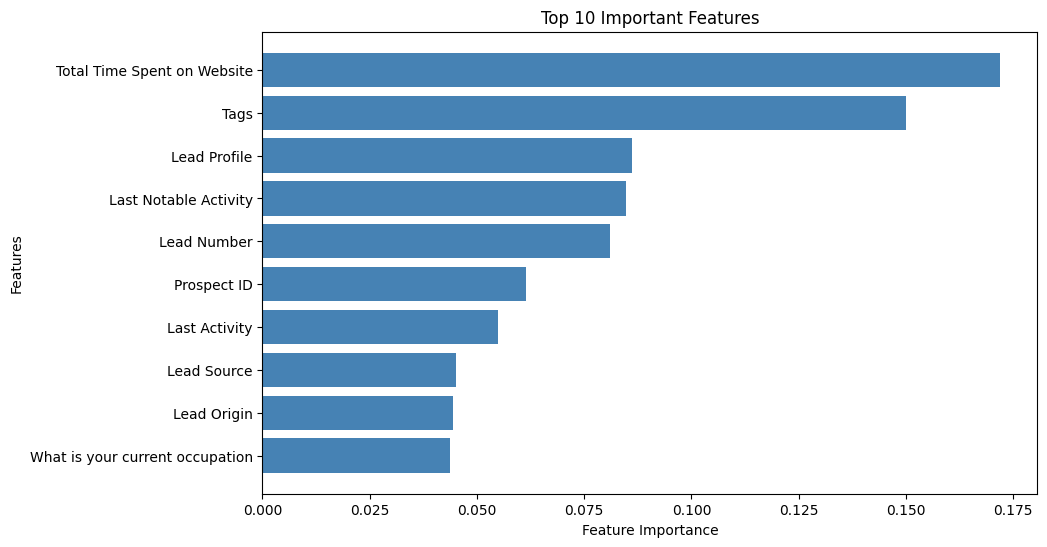

In [40]:
# ==========================================
# Feature Importance Plot
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10],
    color="steelblue"
)

plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [41]:
# ==========================================
# Business Insights
# ==========================================

print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print(f"Logistic Regression Accuracy : {accuracy_score(y_test, y_pred_lr):.2%}")
print(f"Random Forest Accuracy       : {accuracy_score(y_test, y_pred_rf):.2%}")

print(f"\nLogistic Regression ROC-AUC : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Random Forest ROC-AUC       : {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nFinal Selected Model : Random Forest")

print("\nKey Insights")
print("-"*40)
print("• Random Forest achieved the highest prediction accuracy.")
print("• Lead Scores help identify high-potential customers.")
print("• High-priority leads should be contacted first.")
print("• Sales effort can be focused on prospects with higher conversion probability.")
print("• This approach can improve sales efficiency and resource utilization.")

BUSINESS INSIGHTS
Logistic Regression Accuracy : 76.62%
Random Forest Accuracy       : 89.72%

Logistic Regression ROC-AUC : 0.8186
Random Forest ROC-AUC       : 0.9597

Final Selected Model : Random Forest

Key Insights
----------------------------------------
• Random Forest achieved the highest prediction accuracy.
• Lead Scores help identify high-potential customers.
• High-priority leads should be contacted first.
• Sales effort can be focused on prospects with higher conversion probability.
• This approach can improve sales efficiency and resource utilization.


In [42]:
# ==========================================
# Project Conclusion
# ==========================================

print("="*60)
print("PROJECT CONCLUSION")
print("="*60)

print("""
Project Objective
-----------------
Develop a Machine Learning model to predict whether a lead
will convert into a customer and assign a Lead Score.

Work Completed
--------------
✓ Loaded and explored the dataset.
✓ Cleaned missing values.
✓ Performed Exploratory Data Analysis (EDA).
✓ Encoded categorical variables.
✓ Split the data into training and testing sets.
✓ Trained Logistic Regression and Random Forest models.
✓ Compared model performance using Accuracy and ROC-AUC.
✓ Generated Lead Scores (0–100).
✓ Classified leads into High, Medium and Low Priority.

Final Results
-------------
Logistic Regression Accuracy : {:.2%}
Random Forest Accuracy       : {:.2%}

Logistic Regression ROC-AUC  : {:.4f}
Random Forest ROC-AUC        : {:.4f}

Final Model
-----------
Random Forest was selected because it achieved the highest
Accuracy and ROC-AUC score.

Business Impact
---------------
The Lead Scoring model enables X Education to prioritize
high-quality leads, reduce effort spent on low-potential
prospects, and support better allocation of sales resources.
""".format(
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_prob_lr),
    roc_auc_score(y_test, y_prob_rf)
))

PROJECT CONCLUSION

Project Objective
-----------------
Develop a Machine Learning model to predict whether a lead
will convert into a customer and assign a Lead Score.

Work Completed
--------------
✓ Loaded and explored the dataset.
✓ Cleaned missing values.
✓ Performed Exploratory Data Analysis (EDA).
✓ Encoded categorical variables.
✓ Split the data into training and testing sets.
✓ Trained Logistic Regression and Random Forest models.
✓ Compared model performance using Accuracy and ROC-AUC.
✓ Generated Lead Scores (0–100).
✓ Classified leads into High, Medium and Low Priority.

Final Results
-------------
Logistic Regression Accuracy : 76.62%
Random Forest Accuracy       : 89.72%

Logistic Regression ROC-AUC  : 0.8186
Random Forest ROC-AUC        : 0.9597

Final Model
-----------
Random Forest was selected because it achieved the highest
Accuracy and ROC-AUC score.

Business Impact
---------------
The Lead Scoring model enables X Education to prioritize
high-quality leads, reduce 

# Lead Scoring Prediction

## Project Overview

This project predicts whether a lead is likely to convert into a customer using Machine Learning.

The model assigns a Lead Score (0–100) and categorizes leads into:

- High Priority
- Medium Priority
- Low Priority

## Dataset

Lead Scoring Dataset (X Education)

## Models Used

- Logistic Regression
- Random Forest

## Results

| Model | Accuracy | ROC-AUC |
|--------|----------|----------|
| Logistic Regression | 76.62% | 0.8186 |
| Random Forest | 89.72% | 0.9597 |

## Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Outcome

The Random Forest model provided the best performance and can help prioritize high-quality leads for the sales team.